# Экспериментальное исследование алгоритмов для регулярных запросов

## Постановка задачи

Задача посвящена анализу производительности следующих задач достижимости с регулярными ограничениями (Regular Path Querying, RPQ):
- Достижимость между всеми парами вершин.
- Достижимость для каждой из заданного множества стартовых вершин.

Вопросы, на которые необходимо ответить в ходе исследования:

- Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?
- Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?


## Описание исследуемых решений

Рассматриваемые решения реализованы в задачах №3 и №4 соответственно.

### Регулярные запросы для всех пар вершин (Tensor-based RPQ)

Решение на основе тензорного произведения. Ограничения в данной задаче заданы регулярными выражениями, по которым можно построить конечные автоматы. Булевая декомпозиция конечного автомата, построенного по графу, пересекается с булевой декомпозицией конечного автомата, построенным по регулярному выражению путем построения тензорного произведения соответствующих матриц смежности. Объединяем все элементы получившейся булевой декомпозиции.
В решении мы работаем с разреженными матрицы смежности из [sciPy](https://docs.scipy.org/doc/scipy/reference/sparse.html) и информацией о стартовых и финальных вершинах. 

Поскольку перед нами стоит задача отвечать на вопрос о достижимости, нам потребуется дополнительно рассчитать транзитивное замыкание путём последовательного возведения матрицы в степень до тех пор, пока результат не перестанет меняться. Результатом работы алгоритма является набор пары вершин из заданных стартовых и финальных, которые связанны путём, формирующем слово из языка, задаваемого регулярным выражением.

### Регулярные запросы для нескольких стартовых вершин (MS BFS-based RPQ)

Алгоритм поиска достижимости от нескольких стартовых вершин через обход в ширину (Multiple-Source BFS), основанный на линейной алгебре. Идея алгоритма основана на одновременном обходе в ширину графа и конечного автомата, построенного по грамматике/регулярному выражению. 

Создаются булевы декомпозиции, построенные из автоматов графа и регулярного выражения. Далее, мы оперируем с двумя словарями, где ключом является символ метки ребра графа или символ алфавита автомата, а значением — соответствующая им булевая матрица. Для каждого символа из пересечения этих множеств строится матрица $D$ как прямая сумма булевых матриц (блочно-диагональная матрица, составленная из исходных матриц, расположенных по диагонали). Для каждой стартовой вершины формируется матрица состояния (фронт), отражающая текущее множество пар (вершина графа, состояние автомата, соответствующего регулярному выражению запроса). Умножаем фронт на элементы булевой декомпозиции, складываем результат (новые достижимые состояния, соответствующие ограничениям) к числу посещенных состояний. Все это повторяется до тех пор, пока матрица состояний (фронтов) не станет пустой (т.е. не появятся новые достижимые состояния). 

Результатом работы алгоритма будет множество пар вершин $(v, w)$ графа таких, что вершина $w$ достижима из множества начальных вершин, а $v$ принадлежит множеству начальных вершин

## Набор данных

### Графы

Графы были выбраны из набора [CFPQ_Data](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html). 

В таблице приведены данные графов, выбранных для исследования:

| Граф  | Количество вершин | Количество ребер | Уникальные метки |
|-------|-------------------|------------------|------------------|
| atom  | 291               | 425              | 17               |
| foaf  | 256               | 631              | 15               |
| wc    | 332               | 269              | 2                |
| skos  | 144               | 252              | 21               |

Выбор такого набора обусловлен различиями в их плотности (соотношении числа вершин и ребер). В него вошли как сбалансированные структуры, так и графы с преобладанием ребер над вершинами. Кроме того, при формировании выборки учитывался размер графов: он выбирался таким образом, чтобы обеспечить возможность проведения измерений за приемлемое время.

### Запросы

Запросы сформированы по шаблону, использующий все основные операции над регулярными языками (замыкание, конкатенация, альтернатива):

- ```(l1 | l2)* l3```
- ```(l3 | l4)+ l1*```
- ```l1 l2 l3 (l4|l1)*```
- ```l1 (l2 | l3)* l4 ```

Где $l1$,&ensp;$l2$,&ensp;$l3$,&ensp;$l4$ — самые часто встречающиеся метки в графе (если меток всего 2, как у ```wc```, то считаем, что $l1$&ensp;=&ensp;$l3$,&ensp;а &ensp;$l2$&ensp;=&ensp;$l4$).

Запросы различаются по количеству состояний и переходов в конечном автомате, что влияет на размер и разреженность матрицы смежности.

## Оборудование

- **Операционная система**: MacOS Sequoia 15.6.1
- **Процессор**: Apple M2 8 ядер
- **ОЗУ**: 8GB RAM
- **ПЗУ**: 256GB SSD
- **Версия Python**: 3.12.5

## Этапы проведения эксперимента

#### 1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?

Были выбраны четыре представления разреженных матриц:
- [csc_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csc_matrix.html#scipy.sparse.csc_matrix)
- [csr_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.html#scipy.sparse.csr_matrix)
- [dok_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_matrix.html#scipy.sparse.dok_matrix)
- [lil_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html#scipy.sparse.lil_matrix)

Все они являются частью библиотеки `scipy.sparse` и поддерживают все необходимые в ходе эксперимента операции. Для каждой комбинации типа разреженной матрицы, графа и регулярного выражения оба алгоритма выполняются по 20 раз. В качестве стартовых и финальных вершин графа выберем все вершины. 

#### 2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

Размер стартового множества определяется процентом от общего числа вершин графа, и в качестве рассматриваемых размеров стартовых множеств были выбраны 10%, 30%, 70% и 100% - такой набор позволит рассмотреть большой диапазон значений при относительно небольшых количествах запусков.

Для каждого регулярного выражения и каждого графа будут проводиться измерения времени выполнения обоих алгоритмов при различных размерах стартового множества. Как и в ответе для первого вопроса, для каждой конфигурации будет 20 запусков.



В качестве итоговой оценки производительности для ответа на оба вопроса будет использоваться среднее время выполнения, а также рассчитан 95% доверительный интервал.


## Ход эксперимента

#### Импорты и глобальные переменные

In [15]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd()))

import cfpq_data
import logging
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

from scipy.sparse import csc_matrix, csr_matrix, dok_matrix, lil_matrix
from collections import defaultdict, Counter
from cfpq_data import get_sorted_labels

from project.task3 import tensor_based_rpq
from project.task4 import ms_bfs_based_rpq

logging.getLogger().setLevel(logging.ERROR)


NUM_RUNS = 5
RANDOM_SEED = 42
GRAPHS_NAMES = ["atom", "foaf", "wc", "skos"]
REGEX_TEMPLATES = [
    "(l1|l2)* · l3",
    "(l3|l4)+ · l1*",
    "(l1 · l2 · l3 · (l4|l1)*)",
    "(l1 · (l2|l3)* · l4)",
]
SCIPY_MATRIX = [csc_matrix, csr_matrix, dok_matrix, lil_matrix]

#### Сравнение графов

In [2]:
graphs_info = defaultdict(dict)

for name in GRAPHS_NAMES:
    path = cfpq_data.download(name)
    g = cfpq_data.graph_from_csv(path)

    vertices = g.number_of_nodes()
    edges = g.number_of_edges()

    labels = set()
    for _, _, data in g.edges(data=True):
        labels.add(data["label"])
    
    
    graphs_info[name] = {'vertices': vertices, 'edges': edges, 'labels': labels}

In [3]:
for name, info in graphs_info.items():
    print(f"{name}")
    for key, value in info.items():
        print(f"  - {key}: {value}")

atom
  - vertices: 291
  - edges: 425
  - labels: {'imports', 'subClassOf', 'versionInfo', 'label', 'subPropertyOf', 'seeAlso', 'publisher', 'domain', 'date', 'comment', 'range', 'title', 'creator', 'type', 'language', 'format', 'description'}
foaf
  - vertices: 256
  - edges: 631
  - labels: {'subClassOf', 'disjointWith', 'label', 'term_status', 'subPropertyOf', 'isDefinedBy', 'domain', 'comment', 'range', 'equivalentClass', 'title', 'type', 'equivalentProperty', 'description', 'inverseOf'}
wc
  - vertices: 332
  - edges: 269
  - labels: {'a', 'd'}
skos
  - vertices: 144
  - edges: 252
  - labels: {'subClassOf', 'scopeNote', 'unionOf', 'range', 'creator', 'contributor', 'disjointWith', 'isDefinedBy', 'example', 'type', 'inverseOf', 'subPropertyOf', 'seeAlso', 'first', 'comment', 'description', 'label', 'definition', 'rest', 'domain', 'title'}


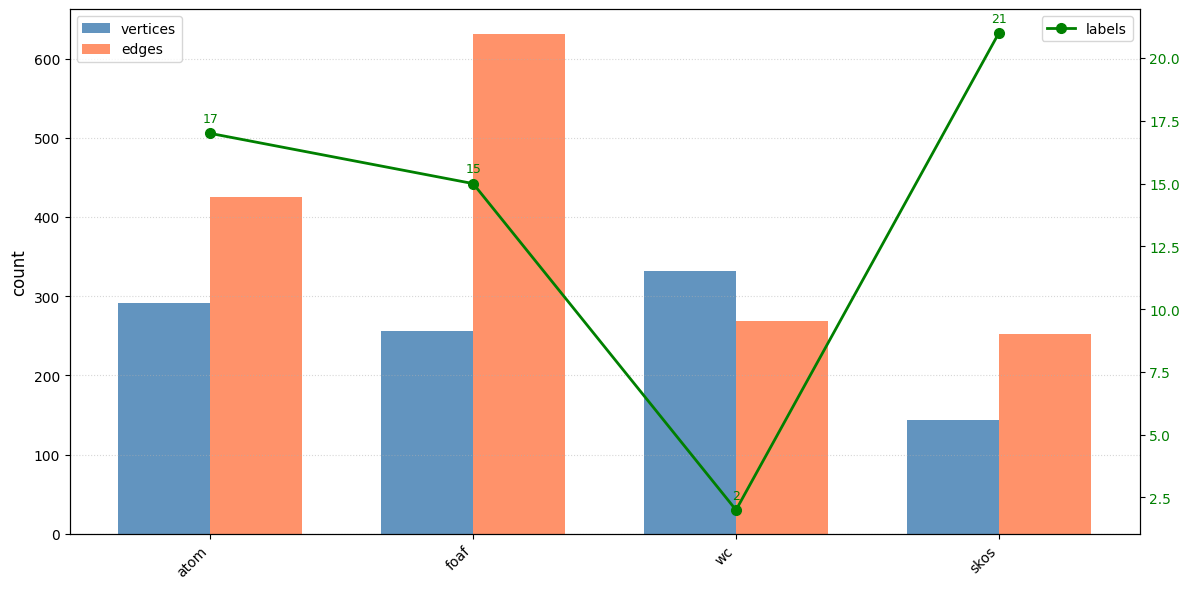

In [4]:
names = list(graphs_info.keys())
vertices = [graphs_info[n]['vertices'] for n in names]
edges    = [graphs_info[n]['edges']    for n in names]
n_labels = [len(graphs_info[n]['labels']) for n in names]

x = np.arange(len(names))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

bars1 = ax1.bar(x - bar_width / 2, vertices, bar_width, label='vertices', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x + bar_width / 2, edges,    bar_width, label='edges',    color='coral',     alpha=0.85)

ax1.set_ylabel('count', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.5, axis='y', zorder=0)

ax2 = ax1.twinx()
ax2.plot(x, n_labels, marker='o', color='green', linewidth=2,
         markersize=7, label='labels', zorder=3)
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right', fontsize=10)

for i, val in enumerate(n_labels):
    ax2.annotate(str(val), (x[i], val),
                 textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=9, color='green')
plt.tight_layout()
plt.show()

#### Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач

Формируем регулярное выражение на основе четырех меток

In [5]:
def build_regex_from_labels(labels):
    if len(labels) < 4:
        l1, l2, *_ = labels
        return [
        f"({l1}|{l2})* {l1}",
        f"({l1}|{l2})+ {l1}*",
        f"({l1} {l2} {l1} ({l2}|{l1})*)",
        f"({l1} ({l2}|{l1})* {l2})",
    ]
    else:
        l1, l2, l3, l4, *_ = labels
        return [
            f"({l1}|{l2})* {l3}",
            f"({l3}|{l4})+ {l1}*",
            f"({l1} {l2} {l3} ({l4}|{l1})*)",
            f"({l1} ({l2}|{l3})* {l4})",
        ]

In [7]:
graphs = {g: cfpq_data.graph_from_csv(cfpq_data.download(g)) for g in GRAPHS_NAMES}
methods = ['tensor_based_rpq', 'ms_bfs_based_rpq']

In [12]:
def run(method, graph, regex, matrix):
    times = []

    for _ in range(NUM_RUNS):
        start_time = time.time()
        if method == 'tensor_based_rpq':
            tensor_based_rpq(regex, graph, graph.nodes, graph.nodes, matrix)
        elif method == 'ms_bfs_based_rpq':
            ms_bfs_based_rpq(regex, graph, graph.nodes, graph.nodes, matrix)
        else:
            raise Exception('this algorithm is not supported')
        
        final_time = time.time()
        times.append(final_time - start_time)
    
    avg = sum(times) / len(times)

    return avg

In [26]:
results = []

for method in methods:
    for name, graph in graphs.items():
        labels = get_sorted_labels(graph)
        most_common_labels = [label for label, _ in Counter(labels).most_common(4)]
        regexes = build_regex_from_labels(labels)

        print(method)
        print(f"graph {name}")
        print(labels)
        print(most_common_labels)
        print(regexes)

        for regex_idx, regex in enumerate(regexes):
            for matrix in SCIPY_MATRIX:
                res_time = run(method, graph, regex, matrix)

                results.append({
                    "method": method,
                    "regex": regex,
                    "regex_template": REGEX_TEMPLATES[regex_idx],
                    "graph": name,
                    "matrix": matrix.__name__,
                    "avg_time": res_time
                })

tensor_based_rpq
graph atom
['type', 'label', 'subClassOf', 'comment', 'domain', 'range', 'subPropertyOf', 'creator', 'date', 'description', 'format', 'imports', 'language', 'publisher', 'seeAlso', 'title', 'versionInfo']
['type', 'label', 'subClassOf', 'comment']
['(type|label)* subClassOf', '(subClassOf|comment)+ type*', '(type label subClassOf (comment|type)*)', '(type (label|subClassOf)* comment)']


/Users/kseniia/formal-lang-course/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/kseniia/formal-lang-course/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


tensor_based_rpq
graph foaf
['type', 'label', 'comment', 'term_status', 'isDefinedBy', 'domain', 'range', 'subPropertyOf', 'subClassOf', 'disjointWith', 'inverseOf', 'equivalentClass', 'description', 'equivalentProperty', 'title']
['type', 'label', 'comment', 'term_status']
['(type|label)* comment', '(comment|term_status)+ type*', '(type label comment (term_status|type)*)', '(type (label|comment)* term_status)']
tensor_based_rpq
graph wc
['d', 'a']
['d', 'a']
['(d|a)* d', '(d|a)+ d*', '(d a d (a|d)*)', '(d (a|d)* a)']
tensor_based_rpq
graph skos
['type', 'definition', 'isDefinedBy', 'label', 'subPropertyOf', 'comment', 'scopeNote', 'inverseOf', 'range', 'domain', 'contributor', 'disjointWith', 'creator', 'example', 'first', 'rest', 'description', 'seeAlso', 'subClassOf', 'title', 'unionOf']
['type', 'definition', 'isDefinedBy', 'label']
['(type|definition)* isDefinedBy', '(isDefinedBy|label)+ type*', '(type definition isDefinedBy (label|type)*)', '(type (definition|isDefinedBy)* label)

In [27]:
df = pd.DataFrame(results)
df

,method,regex,regex_template,graph,matrix,avg_time
0,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csc_matrix,0.109009
1,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csr_matrix,0.093659
2,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,dok_matrix,0.071829
3,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,lil_matrix,0.084734
4,tensor_based_rpq,(subClassOf|comment)+ type*,(l3|l4)+ · l1*,atom,csc_matrix,0.152673
...,...,...,...,...,...,...
123,ms_bfs_based_rpq,(type definition isDefinedBy (label|type)*),(l1 · l2 · l3 · (l4|l1)*),skos,lil_matrix,0.080814
124,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csc_matrix,0.089829
125,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csr_matrix,0.086124
126,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,dok_matrix,0.108367


In [28]:
MATRIX_TYPES = sorted(df['matrix'].unique())
DF_REGEX = list(df['regex_template'].unique())

print(DF_REGEX)

['(l1|l2)* · l3', '(l3|l4)+ · l1*', '(l1 · l2 · l3 · (l4|l1)*)', '(l1 · (l2|l3)* · l4)']


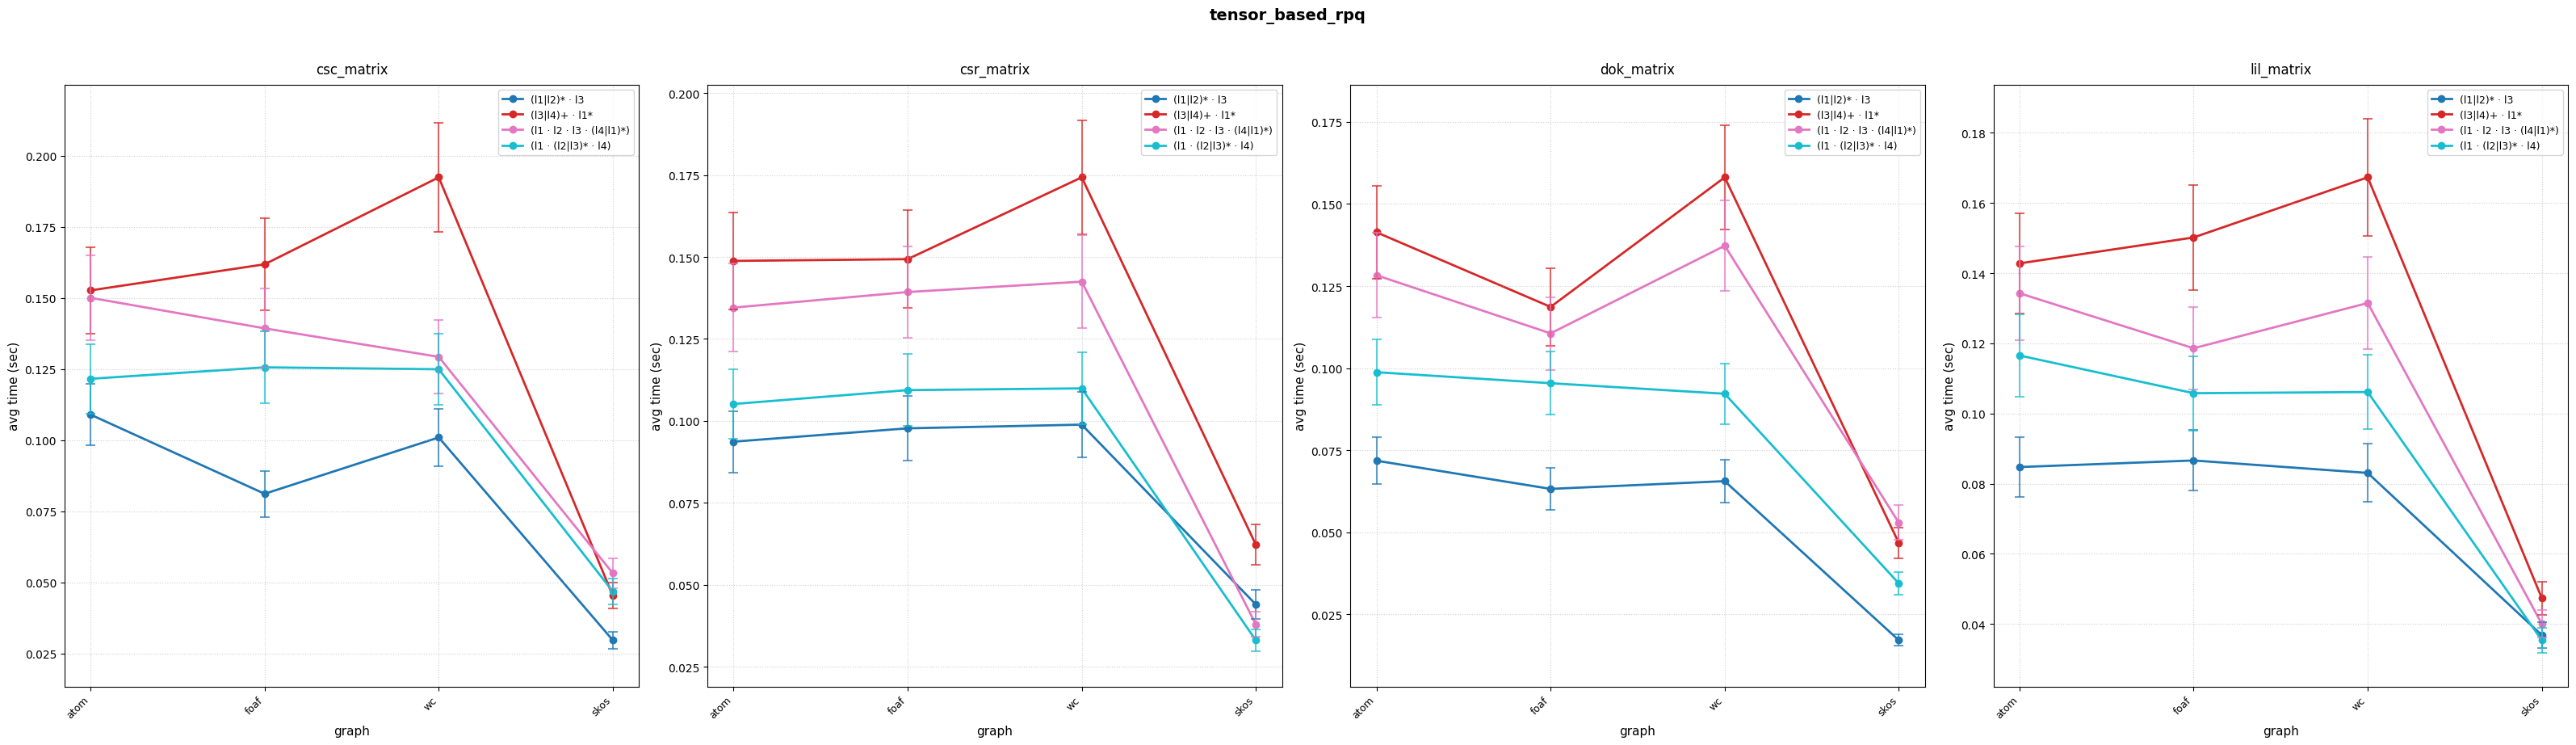

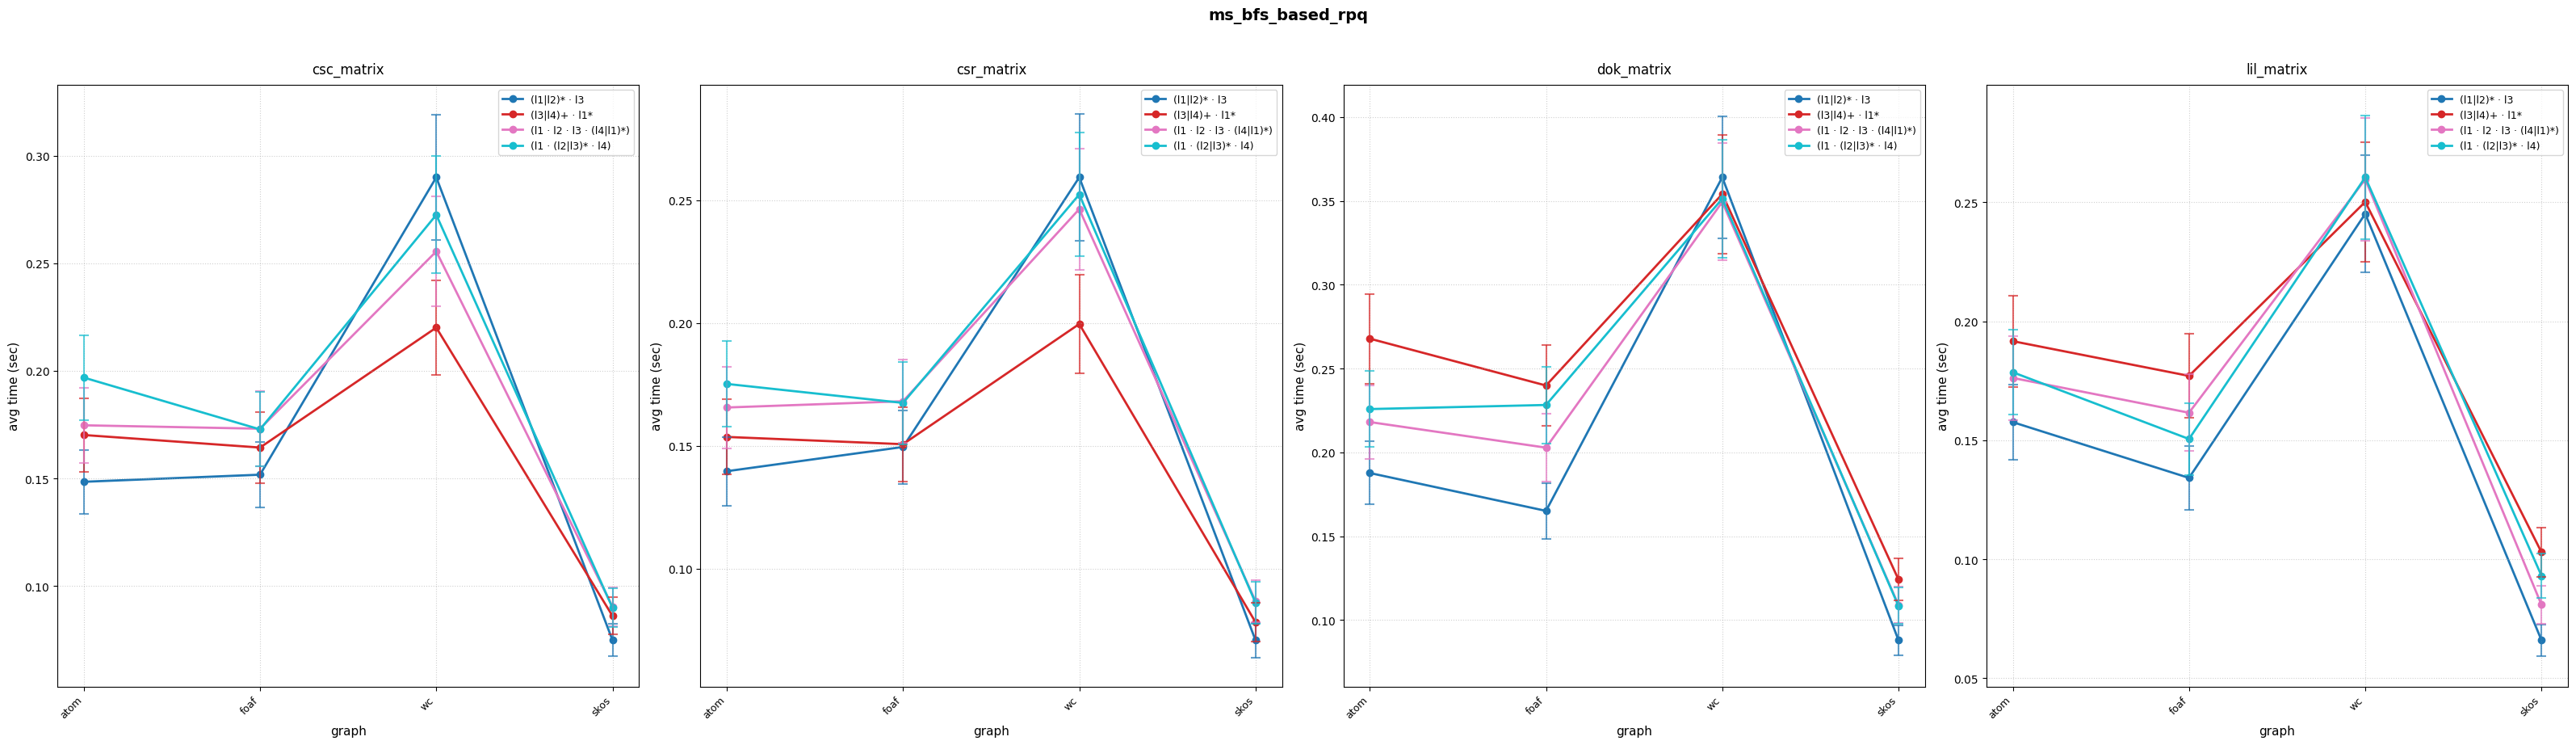

In [30]:
# tensor_based_rpq

METHOD_NAME = 'tensor_based_rpq'
method_data_all = df[df['method'] == METHOD_NAME]

regex_colors = plt.cm.tab10(np.linspace(0, 1, len(DF_REGEX)))
graph_names = list(graphs.keys())

fig, axes = plt.subplots(1, len(MATRIX_TYPES), figsize=(8 * len(MATRIX_TYPES), 9), sharey=False)
fig.suptitle(METHOD_NAME, fontsize=14, fontweight='bold', y=1.02)

for idx, matrix_type in enumerate(MATRIX_TYPES):
    ax = axes[idx]
    matrix_data = method_data_all[method_data_all['matrix'] == matrix_type]
    all_y_vals = []

    for regex_idx, regex in enumerate(DF_REGEX):
        regex_data = matrix_data[matrix_data['regex_template'] == regex]
        x_vals, y_vals, yerr_vals = [], [], []

        for g_idx, graph_name in enumerate(graph_names):
            row = regex_data[regex_data['graph'] == graph_name]
            if not row.empty:
                mean_time = row['avg_time'].iloc[0]
                x_vals.append(g_idx)
                y_vals.append(mean_time)
                yerr_vals.append(mean_time * 0.1)

        if not x_vals:
            continue

        all_y_vals.extend(y_vals)
        color = regex_colors[regex_idx]
        ax.plot(
            x_vals, y_vals,
            marker="o", linestyle="-", color=color,
            label=regex, zorder=1, linewidth=2, markersize=6,
        )
        ax.errorbar(
            x_vals, y_vals, yerr=yerr_vals,
            fmt="none", ecolor=color, alpha=0.7,
            capsize=4, capthick=1.5, zorder=2,
        )

    ax.set_title(f"{matrix_type}", fontsize=12, pad=10)
    ax.set_xlabel("graph", fontsize=11)
    ax.set_ylabel("avg time (sec)", fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6, zorder=0)
    ax.set_xticks(range(len(graph_names)))
    ax.set_xticklabels(graph_names, rotation=45, ha="right", fontsize=9)

    if all_y_vals:
        y_min, y_max = min(all_y_vals), max(all_y_vals)
        y_range = y_max - y_min
        ax.set_ylim(max(0, y_min - y_range * 0.1), y_max + y_range * 0.2)

plt.tight_layout()
plt.show()

# БЛОК 2: ms_bfs_based_rpq

METHOD_NAME = 'ms_bfs_based_rpq'
method_data_all = df[df['method'] == METHOD_NAME]

fig, axes = plt.subplots(1, len(MATRIX_TYPES), figsize=(8 * len(MATRIX_TYPES), 9), sharey=False)
fig.suptitle(METHOD_NAME, fontsize=14, fontweight='bold', y=1.02)

for idx, matrix_type in enumerate(MATRIX_TYPES):
    ax = axes[idx]
    matrix_data = method_data_all[method_data_all['matrix'] == matrix_type]
    all_y_vals = []

    for regex_idx, regex in enumerate(DF_REGEX):
        regex_data = matrix_data[matrix_data['regex_template'] == regex]
        x_vals, y_vals, yerr_vals = [], [], []

        for g_idx, graph_name in enumerate(graph_names):
            row = regex_data[regex_data['graph'] == graph_name]
            if not row.empty:
                mean_time = row['avg_time'].iloc[0]
                x_vals.append(g_idx)
                y_vals.append(mean_time)
                yerr_vals.append(mean_time * 0.1)

        if not x_vals:
            continue

        all_y_vals.extend(y_vals)
        color = regex_colors[regex_idx]
        ax.plot(
            x_vals, y_vals,
            marker="o", linestyle="-", color=color,
            label=regex, zorder=1, linewidth=2, markersize=6,
        )
        ax.errorbar(
            x_vals, y_vals, yerr=yerr_vals,
            fmt="none", ecolor=color, alpha=0.7,
            capsize=4, capthick=1.5, zorder=2,
        )

    ax.set_title(f"{matrix_type}", fontsize=12, pad=10)
    ax.set_xlabel("graph", fontsize=11)
    ax.set_ylabel("avg time (sec)", fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6, zorder=0)
    ax.set_xticks(range(len(graph_names)))
    ax.set_xticklabels(graph_names, rotation=45, ha="right", fontsize=9)

    if all_y_vals:
        y_min, y_max = min(all_y_vals), max(all_y_vals)
        y_range = y_max - y_min
        ax.set_ylim(max(0, y_min - y_range * 0.1), y_max + y_range * 0.2)

plt.tight_layout()
plt.show()

#### Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

In [ ]:
start_nodes_proportion = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]